# BERT Alignment: How Text-Like Is the Emotion Geometry in Speech Encoders?

**Task 7 -- CSCI 535 Final Project**

Given only emotion labels (no transcripts), ask: *does the class-centroid geometry of
each speech layer match the class-centroid geometry of BERT's emotion-word embeddings?*

For each (model, dataset, layer) triple we compute three complementary alignment metrics:

1. **Linear CKA** between per-sample speech representations and per-sample BERT vectors,
   where each sample's BERT vector = the BERT [CLS] embedding of its label word.
2. **Procrustes disparity** between class-centroid matrices in speech space vs BERT
   emotion-word space -- measures manifold match up to rotation.
3. **Cross-modal nearest-centroid accuracy** -- can BERT emotion centroids classify
   speech samples via centroid matching alone?

All three give a (num_layers,) curve per experiment. High alignment at a given layer
means the speech encoder organizes emotions the same way BERT organizes emotion words
-- a text-free sanity check that the frozen probing results aren't just capturing
acoustic artefacts.

**Scope** -- 6 speech models x 7 datasets = 42 alignment experiments.

**Text encoder**: `bert-base-uncased` (768-dim [CLS] pooling, 12-layer transformer).


In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from scipy.linalg import orthogonal_procrustes
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
# Transformers is only needed once to embed the label words.
from transformers import AutoTokenizer, AutoModel

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")


Using device: mps


## 1. Configuration & Path Resolution

Same resolver as the Layer Mixer notebook -- walks all `Embedding-Files*` splits plus
legacy EXP3 folders and indexes every `.npy` file once.


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================
PROJECT_ROOT = '/Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final'
NIMA_EMBEDDINGS_ROOT = os.path.join(PROJECT_ROOT, 'embeddings_npyfiles')
EXP3_DIR   = os.path.join(PROJECT_ROOT, 'EXP3', 'embeddings')
EXP3_2_DIR = os.path.join(PROJECT_ROOT, 'EXP3 2', 'embeddings')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'my_code', 'results', 'bert_alignment')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# MODELS / DATASETS -- 6 speech models x 7 datasets
# ============================================================
MODELS = ['wav2vec2', 'HuBERT', 'Whisper', 'WavLM', 'MERT', 'w2v-BERT']
DATASETS = ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD', 'MSP-Podcast']

# ============================================================
# FILE INDEX -- walk all Embedding-Files splits + legacy EXP3
# ============================================================
_EMB_PATTERN = re.compile(
    r"^(hidden_states|filenames|labels)_([A-Za-z0-9\-]+)_([A-Za-z0-9\-]+?)(?:_SNR(\d+))?\.npy$"
)


def _build_embedding_index():
    index = {}
    if os.path.isdir(NIMA_EMBEDDINGS_ROOT):
        for top in sorted(os.listdir(NIMA_EMBEDDINGS_ROOT)):
            if not top.startswith('Embedding-Files'):
                continue
            top_path = os.path.join(NIMA_EMBEDDINGS_ROOT, top)
            if not os.path.isdir(top_path):
                continue
            for sub in ('clean-embeddings', 'noisy-embeddings'):
                emb_dir = os.path.join(top_path, sub, 'embeddings')
                if not os.path.isdir(emb_dir):
                    continue
                for fname in os.listdir(emb_dir):
                    if not fname.endswith('.npy'):
                        continue
                    m = _EMB_PATTERN.match(fname)
                    if not m:
                        continue
                    prefix, model, dataset, snr = (
                        m.group(1), m.group(2), m.group(3),
                        f'SNR{m.group(4)}' if m.group(4) else 'clean',
                    )
                    key = (prefix, model, dataset, snr)
                    if key not in index:
                        index[key] = os.path.join(emb_dir, fname)
    for legacy_dir in (EXP3_2_DIR, EXP3_DIR):
        if not os.path.isdir(legacy_dir):
            continue
        for fname in os.listdir(legacy_dir):
            if not fname.endswith('.npy'):
                continue
            m = _EMB_PATTERN.match(fname)
            if not m:
                continue
            prefix, model, dataset, snr = (
                m.group(1), m.group(2), m.group(3),
                f'SNR{m.group(4)}' if m.group(4) else 'clean',
            )
            key = (prefix, model, dataset, snr)
            if key not in index:
                index[key] = os.path.join(legacy_dir, fname)
    return index


EMB_INDEX = _build_embedding_index()
print(f"Indexed {len(EMB_INDEX)} .npy files across all folders.")


def resolve_hidden_states_path(model, dataset, snr='clean'):
    key = ('hidden_states', model, dataset, snr)
    if key in EMB_INDEX:
        return EMB_INDEX[key]
    raise FileNotFoundError(f"Missing hidden_states: {model}/{dataset}/{snr}")


def resolve_labels_path(model, dataset, snr='clean'):
    key = ('labels', model, dataset, snr)
    if key in EMB_INDEX:
        return EMB_INDEX[key]
    for other in MODELS:
        fkey = ('labels', other, dataset, snr)
        if fkey in EMB_INDEX:
            return EMB_INDEX[fkey]
    raise FileNotFoundError(f"Missing labels: {dataset}/{snr}")


NUM_LAYERS = 25
LAYER_LABELS = ['CNN'] + [str(i) for i in range(1, 25)]

# Plot style matching Nima's post_train.py
PLOT_STYLE = {
    'cka_color':        '#2196F3',
    'procrustes_color': '#FF5722',
    'centroid_color':   '#4CAF50',
    'figsize':          (10, 5),
    'title_fontsize':   14,
    'label_fontsize':   12,
    'tick_fontsize':    10,
    'legend_fontsize':  11,
    'grid_alpha':       0.3,
    'dpi':              300,
}

print(f"Models ({len(MODELS)}): {MODELS}")
print(f"Datasets ({len(DATASETS)}): {DATASETS}")


Indexed 378 .npy files across all folders.
Models (6): ['wav2vec2', 'HuBERT', 'Whisper', 'WavLM', 'MERT', 'w2v-BERT']
Datasets (7): ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD', 'MSP-Podcast']


## 2. Label Vocabulary: Map Each Dataset Label to an English Emotion Word

Nima's labels .npy files use dataset-specific label tokens (e.g. `ang` for IEMOCAP,
`anger` for MSP-Podcast, `W` never -- labels are decoded strings). We normalize every
label to an English emotion word before embedding with BERT, so that the same
underlying emotion across datasets gets the same text vector. This lets us *share*
a single BERT lookup table across all 42 experiments and avoids running BERT 42 times.


In [3]:
# Canonical mapping: dataset-label-token -> English emotion word used for BERT embedding.
# Values chosen so the same emotion always maps to the same English word.
LABEL_TO_WORD = {
    # RAVDESS
    'neutral': 'neutral', 'calm': 'calm', 'happy': 'happy', 'sad': 'sad',
    'angry': 'angry', 'fearful': 'fearful', 'disgust': 'disgust', 'surprised': 'surprised',
    # EmoDB  (already English thanks to Nima's loader)
    'bored': 'bored',
    # IEMOCAP 4-class short codes
    'ang': 'angry', 'hap': 'happy', 'neu': 'neutral', 'sad': 'sad',
    # SAVEE
    'anger': 'angry', 'happiness': 'happy', 'sadness': 'sad',
    'fear': 'fearful', 'surprise': 'surprised',
    # AESDD / MESD -- share SAVEE's labels above ("anger", "happiness", ...)
    # MSP-Podcast 4-class
}


def canonicalize_label(raw_label):
    s = str(raw_label).strip().lower()
    return LABEL_TO_WORD.get(s, s)  # pass through if unknown -- BERT will still embed it


def build_vocab(datasets_iter):
    """Scan every dataset's labels once and return the full set of canonical words."""
    words = set()
    for dataset in datasets_iter:
        try:
            lb_path = resolve_labels_path(MODELS[0], dataset)
        except FileNotFoundError:
            continue
        labels = np.load(lb_path, allow_pickle=True)
        for lb in np.unique(labels):
            words.add(canonicalize_label(lb))
    return sorted(words)


EMOTION_VOCAB = build_vocab(DATASETS)
print(f"Emotion vocabulary across all 7 datasets ({len(EMOTION_VOCAB)}):")
print(" ", EMOTION_VOCAB)


Emotion vocabulary across all 7 datasets (9):
  ['angry', 'bored', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 3. BERT Encoder for Emotion Words

Load `bert-base-uncased` and embed each canonical emotion word once. The prompt
template `"the speaker sounds <word>"` is used so that BERT sees a natural sentential
context rather than a bare token. We take the mean of the last-layer token embeddings
(excluding `[CLS]`/`[SEP]`) as the sentence representation.


In [4]:
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_PROMPT = "the speaker sounds {word}"

print(f"Loading {BERT_MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE).eval()
for p in bert.parameters():
    p.requires_grad_(False)


@torch.no_grad()
def embed_words(words, batch_size=32):
    """Return (len(words), hidden_dim) numpy array of sentence embeddings."""
    vecs = []
    for i in range(0, len(words), batch_size):
        batch = [BERT_PROMPT.format(word=w) for w in words[i:i + batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors='pt').to(DEVICE)
        out = bert(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        # Mean over non-pad tokens
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1)
        vecs.append(pooled.cpu().numpy())
    return np.concatenate(vecs, axis=0)


WORD_EMB = embed_words(EMOTION_VOCAB)
print(f"BERT word embeddings: {WORD_EMB.shape} (n_words, hidden_dim)")
WORD_EMB_LOOKUP = {w: WORD_EMB[i] for i, w in enumerate(EMOTION_VOCAB)}
BERT_DIM = WORD_EMB.shape[1]
print(f"BERT dim: {BERT_DIM}")


Loading bert-base-uncased ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT word embeddings: (9, 768) (n_words, hidden_dim)
BERT dim: 768


## 4. Alignment Metrics

Three metrics, computed per speech layer:

1. **Linear CKA** (Kornblith 2019) -- compares similarity matrices `K = XX^T` and
   `L = YY^T` after centering. Invariant to orthogonal transforms and isotropic
   scaling. Output in `[0, 1]`, higher = more similar.

2. **Procrustes disparity on class centroids** -- compute the mean hidden state per
   class in both speech space and BERT space, then fit an orthogonal transform
   (`scipy.linalg.orthogonal_procrustes`) and report the residual disparity in
   `[0, 2]`. **Lower is better** -- we convert it to an alignment score via
   `score = 1 - disparity / 2`.

3. **Centroid-transfer accuracy** -- project the BERT class centroids onto the speech
   layer's subspace (least-squares ridge regression from centroids to centroids, using
   class-averaged data), then classify speech samples by nearest BERT centroid. This is
   cross-modal retrieval: how well do *text* emotion centroids separate *speech* samples?


In [5]:
def center(X):
    return X - X.mean(axis=0, keepdims=True)


def linear_cka(X, Y):
    """Linear CKA between two (n, d) and (n, d') feature matrices.
    Uses the Frobenius formulation that avoids forming n x n kernels:
      CKA = ||Y^T X||_F^2 / (||X^T X||_F * ||Y^T Y||_F)
    """
    Xc = center(X).astype(np.float64)
    Yc = center(Y).astype(np.float64)
    num = np.linalg.norm(Yc.T @ Xc, ord='fro') ** 2
    den = np.linalg.norm(Xc.T @ Xc, ord='fro') * np.linalg.norm(Yc.T @ Yc, ord='fro')
    if den < 1e-12:
        return 0.0
    return float(num / den)


def procrustes_alignment(centroids_speech, centroids_text):
    """Fit an orthogonal transform between two centroid matrices (k, d_speech) and
    (k, d_text) after projecting to the smaller of the two dims via PCA. Returns
    (disparity, alignment_score) where alignment_score = 1 - disparity / 2 in [0, 1].
    """
    from numpy.linalg import svd
    # Project to common dim = k-1 via SVD on each side (classical Procrustes needs same d)
    A = center(centroids_speech)
    B = center(centroids_text)
    # Pad/truncate to same dim via SVD -> take top-k components on each side
    k = min(A.shape[0], A.shape[1], B.shape[1])
    Ua, Sa, _ = svd(A, full_matrices=False)
    Ub, Sb, _ = svd(B, full_matrices=False)
    A_red = Ua[:, :k] * Sa[:k]
    B_red = Ub[:, :k] * Sb[:k]
    # Normalize each matrix to unit Frobenius norm so disparity is in [0, 2]
    A_norm = A_red / (np.linalg.norm(A_red) + 1e-12)
    B_norm = B_red / (np.linalg.norm(B_red) + 1e-12)
    R, _ = orthogonal_procrustes(A_norm, B_norm)
    disparity = float(np.linalg.norm(A_norm @ R - B_norm) ** 2)
    alignment = 1.0 - disparity / 2.0
    return disparity, max(0.0, min(1.0, alignment))


def centroid_transfer_accuracy(X_speech, y, centroids_text, centroids_speech):
    """Cross-modal classification: use the speech centroids to define per-class means
    in speech space, learn a linear mapping from text centroids to speech centroids,
    and classify each speech sample by nearest mapped text centroid.
    """
    # Ridge regression: W @ text_centroid_i ~= speech_centroid_i
    # Shape: speech (k, d_s) = text (k, d_t) @ W  ->  W = (text^+ speech)
    from numpy.linalg import lstsq
    W, *_ = lstsq(centroids_text, centroids_speech, rcond=None)
    mapped_text_centroids = centroids_text @ W  # (k, d_s)
    # Classify speech samples by nearest mapped centroid (Euclidean)
    dists = np.linalg.norm(
        X_speech[:, None, :] - mapped_text_centroids[None, :, :], axis=2
    )
    preds = dists.argmin(axis=1)
    return float(accuracy_score(y, preds))


def run_alignment_for_layer(X_layer, y, sample_text_vecs,
                            class_speech_centroids, class_text_centroids):
    cka = linear_cka(X_layer, sample_text_vecs)
    _, proc = procrustes_alignment(class_speech_centroids, class_text_centroids)
    xfer = centroid_transfer_accuracy(X_layer, y, class_text_centroids, class_speech_centroids)
    return {'cka': cka, 'procrustes': proc, 'centroid_transfer': xfer}


print("Alignment metric functions defined.")


Alignment metric functions defined.


## 5. Per-Experiment Runner

For each (model, dataset) combo:

1. Load the frozen hidden states + labels
2. Canonicalize labels and look up each sample's BERT sentence embedding
3. Compute per-class centroids on both sides
4. For every layer 0-24, compute the three alignment metrics
5. Return a (num_layers, 3) metric matrix


In [6]:
def run_experiment(model, dataset):
    hs_path = resolve_hidden_states_path(model, dataset)
    lb_path = resolve_labels_path(model, dataset)

    hidden_states = np.load(hs_path, mmap_mode='r')       # (N, 25, 1024)
    labels_raw = np.load(lb_path, allow_pickle=True)       # (N,)

    # Canonicalize labels
    canon_labels = np.array([canonicalize_label(x) for x in labels_raw])
    le = LabelEncoder()
    y = le.fit_transform(canon_labels)
    class_words = list(le.classes_)

    # Per-sample BERT vectors
    sample_text_vecs = np.stack([WORD_EMB_LOOKUP[w] for w in canon_labels])  # (N, 768)

    # Text-side class centroids (one per unique label)
    class_text_centroids = np.stack([WORD_EMB_LOOKUP[w] for w in class_words])  # (k, 768)

    per_layer = []
    for layer_idx in range(hidden_states.shape[1]):
        X_layer = hidden_states[:, layer_idx, :].astype(np.float32)
        # Speech class centroids at this layer
        class_speech_centroids = np.stack([
            X_layer[y == c].mean(axis=0) for c in range(len(class_words))
        ])
        metrics = run_alignment_for_layer(
            X_layer, y, sample_text_vecs,
            class_speech_centroids, class_text_centroids,
        )
        per_layer.append(metrics)

    result = {
        'model': model,
        'dataset': dataset,
        'classes': class_words,
        'num_samples': int(len(y)),
        'cka': np.array([m['cka'] for m in per_layer]),
        'procrustes': np.array([m['procrustes'] for m in per_layer]),
        'centroid_transfer': np.array([m['centroid_transfer'] for m in per_layer]),
    }
    return result


print("run_experiment() defined.")


run_experiment() defined.


## 6. Run All 42 Alignment Experiments

Each experiment is pure numpy linear algebra on frozen embeddings -- expect a few
minutes total on CPU, much faster on GPU-backed torch for the BERT pre-compute
(already done once above).


In [7]:
alignment_results = {}

print(f"{'Model':<10} {'Dataset':<14} {'Best CKA Layer':<18} {'Best Procrustes':<20} {'Best Transfer'}")
print("-" * 95)

for model in MODELS:
    for dataset in DATASETS:
        try:
            res = run_experiment(model, dataset)
        except FileNotFoundError as e:
            print(f"{model:<10} {dataset:<14} *** missing: {e}")
            continue
        alignment_results[(model, dataset)] = res

        best_cka = int(np.argmax(res['cka']))
        best_proc = int(np.argmax(res['procrustes']))
        best_xfer = int(np.argmax(res['centroid_transfer']))
        print(f"{model:<10} {dataset:<14} "
              f"{LAYER_LABELS[best_cka]:<5} ({res['cka'][best_cka]:.3f}) "
              f"   {LAYER_LABELS[best_proc]:<5} ({res['procrustes'][best_proc]:.3f}) "
              f"      {LAYER_LABELS[best_xfer]:<5} ({res['centroid_transfer'][best_xfer]:.3f})")

print(f"\nCompleted {len(alignment_results)} / {len(MODELS) * len(DATASETS)} experiments.")


Model      Dataset        Best CKA Layer     Best Procrustes      Best Transfer
-----------------------------------------------------------------------------------------------


wav2vec2   RAVDESS        10    (0.119)    11    (0.745)       10    (0.604)


wav2vec2   EmoDB          4     (0.119)    7     (0.878)       7     (0.521)


wav2vec2   IEMOCAP        3     (0.044)    16    (0.888)       5     (0.461)


wav2vec2   SAVEE          CNN   (0.044)    14    (0.844)       8     (0.463)


...

w2v-BERT   IEMOCAP        16    (0.037)    1     (0.864)       17    (0.445)


w2v-BERT   SAVEE          8     (0.057)    12    (0.837)       17    (0.517)


w2v-BERT   AESDD          3     (0.084)    CNN   (0.947)       17    (0.656)


w2v-BERT   MESD           3     (0.078)    CNN   (0.848)       3     (0.497)


w2v-BERT   MSP-Podcast    3     (0.011)    11    (0.929)       17    (0.378)

Completed 42 / 42 experiments.


## 7. Per-Layer Alignment Curves

One subplot per (model, dataset), three curves per panel: CKA (blue), Procrustes
alignment (orange), centroid-transfer accuracy (green). X-axis is layer 0..24.


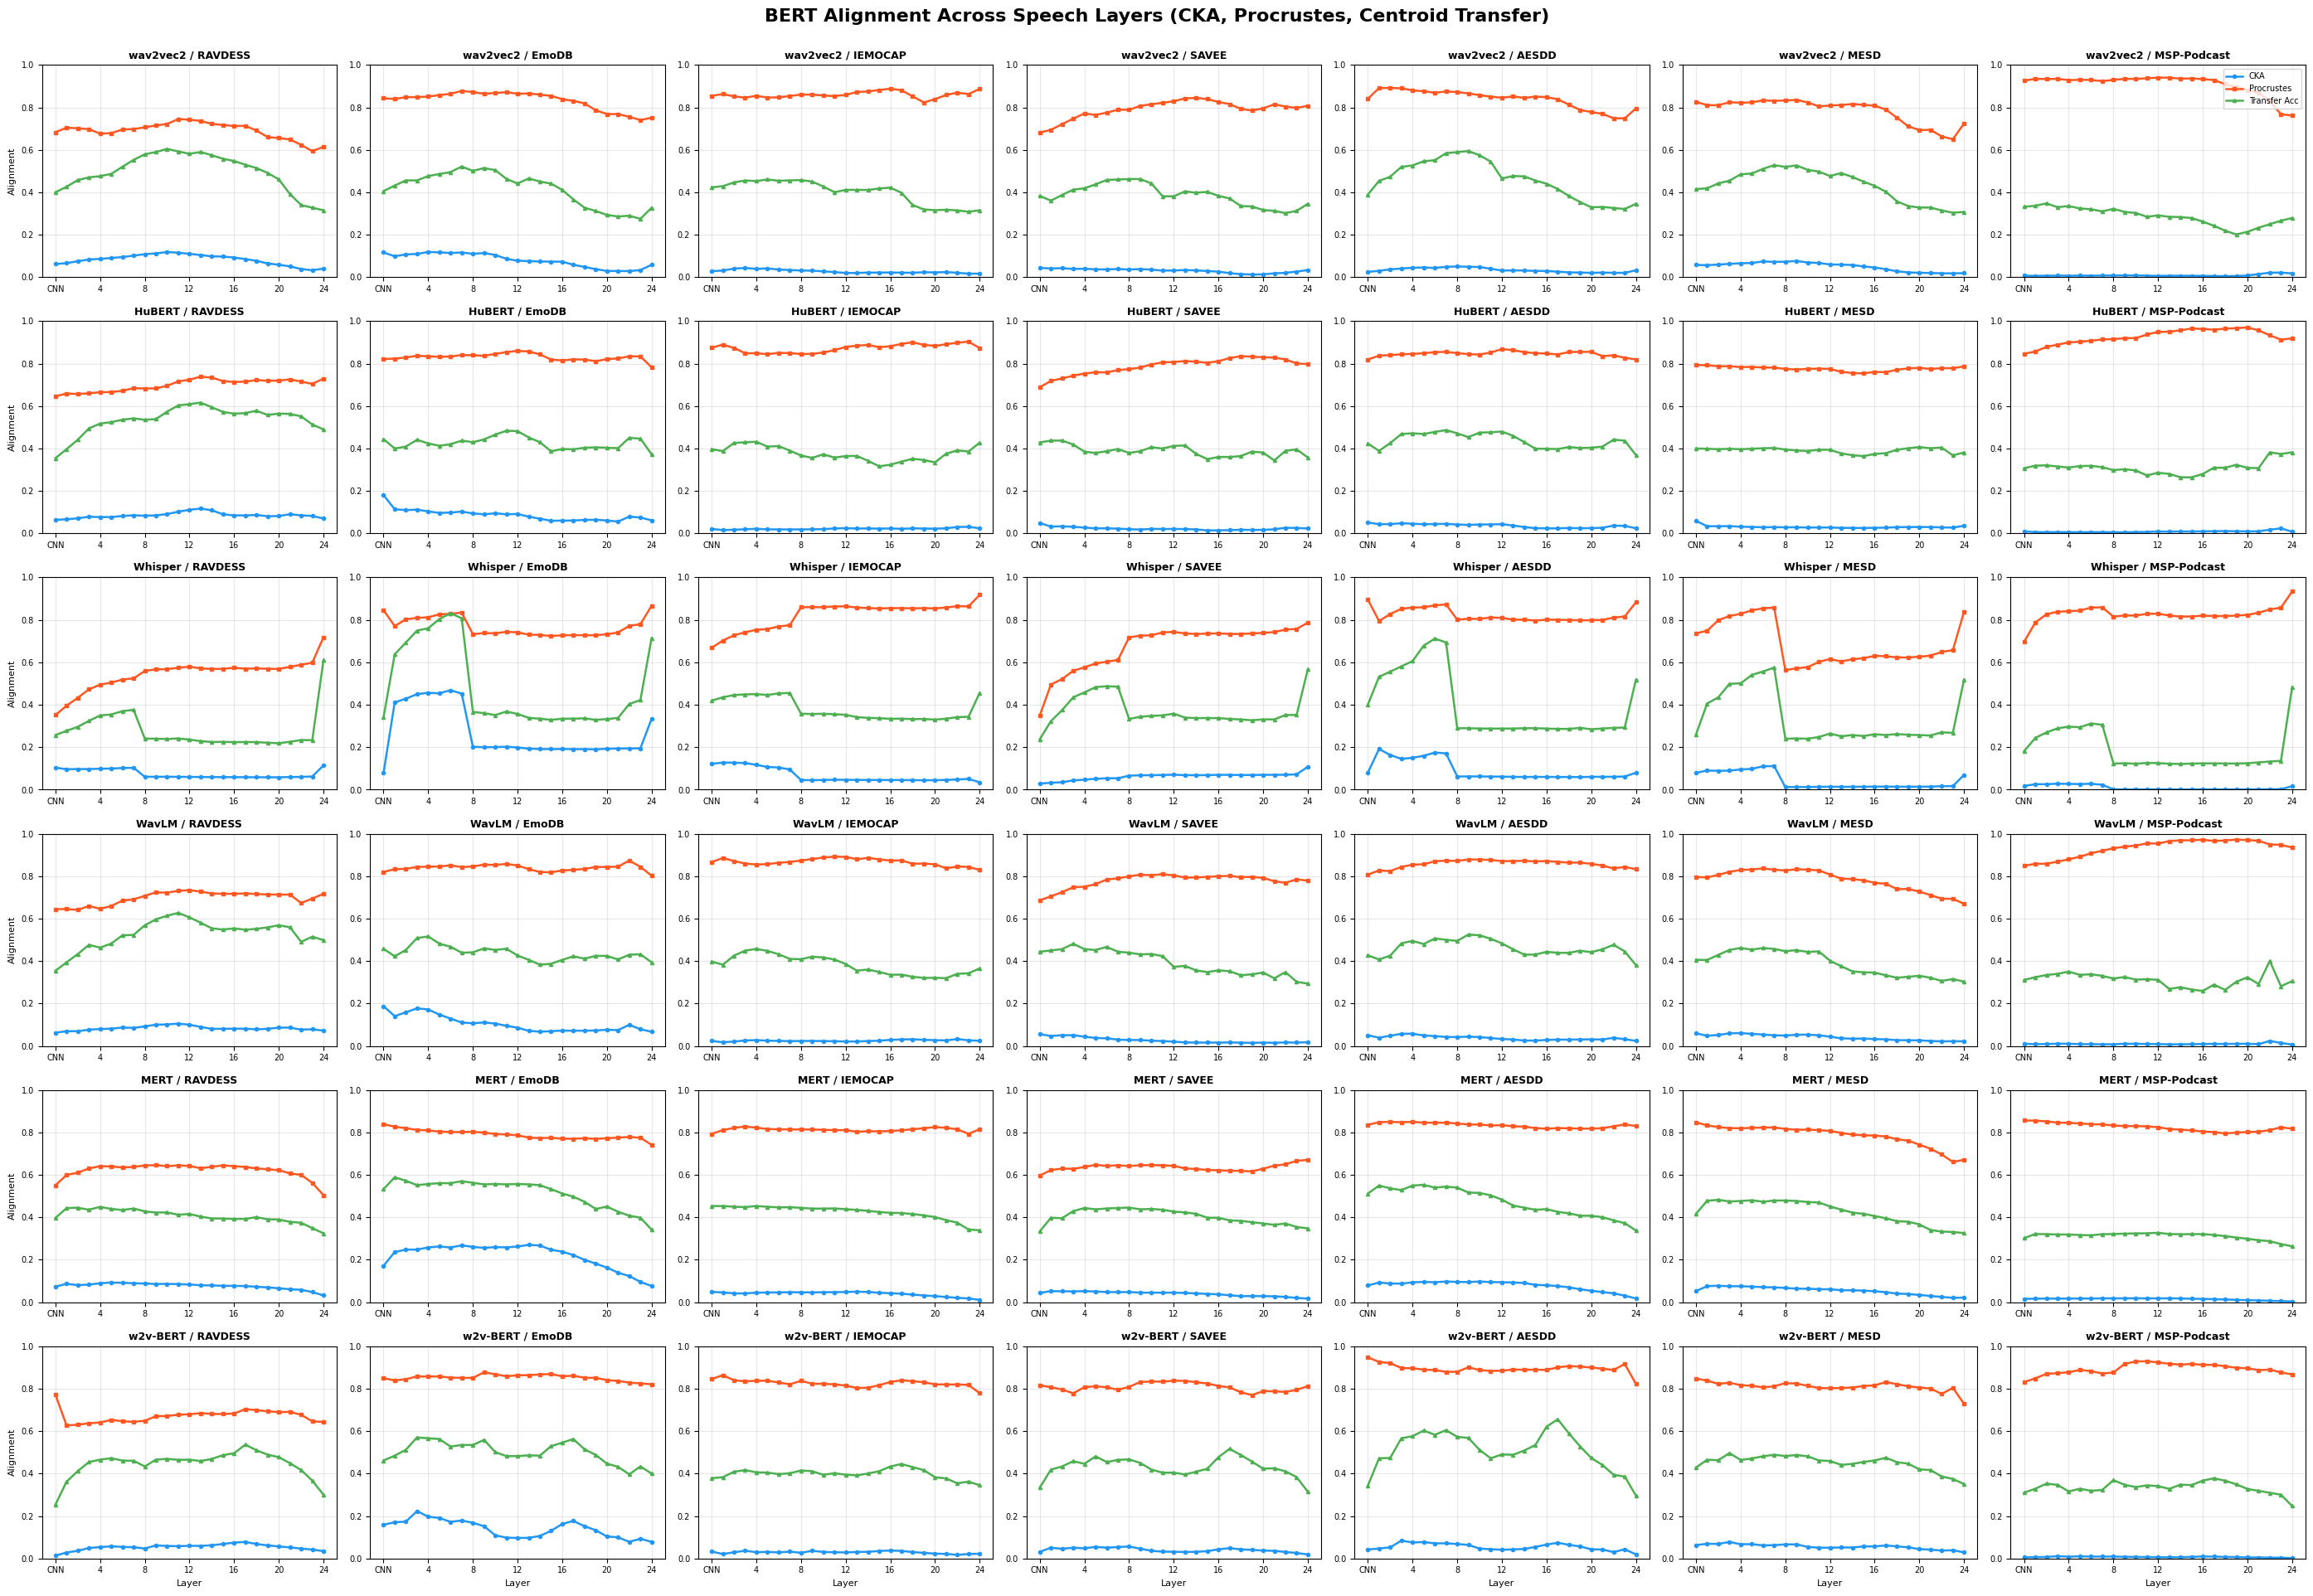

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/alignment_curves_per_experiment.png


In [8]:
n_rows = len(MODELS)
n_cols = len(DATASETS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.2 * n_rows), squeeze=False)

for m_idx, model in enumerate(MODELS):
    for d_idx, dataset in enumerate(DATASETS):
        ax = axes[m_idx][d_idx]
        key = (model, dataset)
        if key not in alignment_results:
            ax.set_visible(False)
            continue

        res = alignment_results[key]
        layers = np.arange(NUM_LAYERS)

        ax.plot(layers, res['cka'], color=PLOT_STYLE['cka_color'], marker='o',
                linewidth=1.8, markersize=3, label='CKA')
        ax.plot(layers, res['procrustes'], color=PLOT_STYLE['procrustes_color'], marker='s',
                linewidth=1.8, markersize=3, label='Procrustes')
        ax.plot(layers, res['centroid_transfer'], color=PLOT_STYLE['centroid_color'], marker='^',
                linewidth=1.8, markersize=3, label='Transfer Acc')

        ax.set_title(f'{model} / {dataset}', fontsize=9, fontweight='bold')
        ax.set_xticks(range(0, 25, 4))
        ax.set_xticklabels([LAYER_LABELS[i] for i in range(0, 25, 4)], fontsize=7)
        ax.set_ylim([0, 1.0])
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])
        if m_idx == 0 and d_idx == n_cols - 1:
            ax.legend(fontsize=7, loc='upper right')
        if m_idx == n_rows - 1:
            ax.set_xlabel('Layer', fontsize=8)
        if d_idx == 0:
            ax.set_ylabel('Alignment', fontsize=8)

plt.suptitle('BERT Alignment Across Speech Layers (CKA, Procrustes, Centroid Transfer)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

out_path = os.path.join(RESULTS_DIR, 'alignment_curves_per_experiment.png')
plt.savefig(out_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {out_path}")


## 8. Alignment Heatmaps per Model

For each metric, one heatmap per speech model: rows = datasets, columns = layers,
cell value = alignment at that layer. Darker = more text-like.


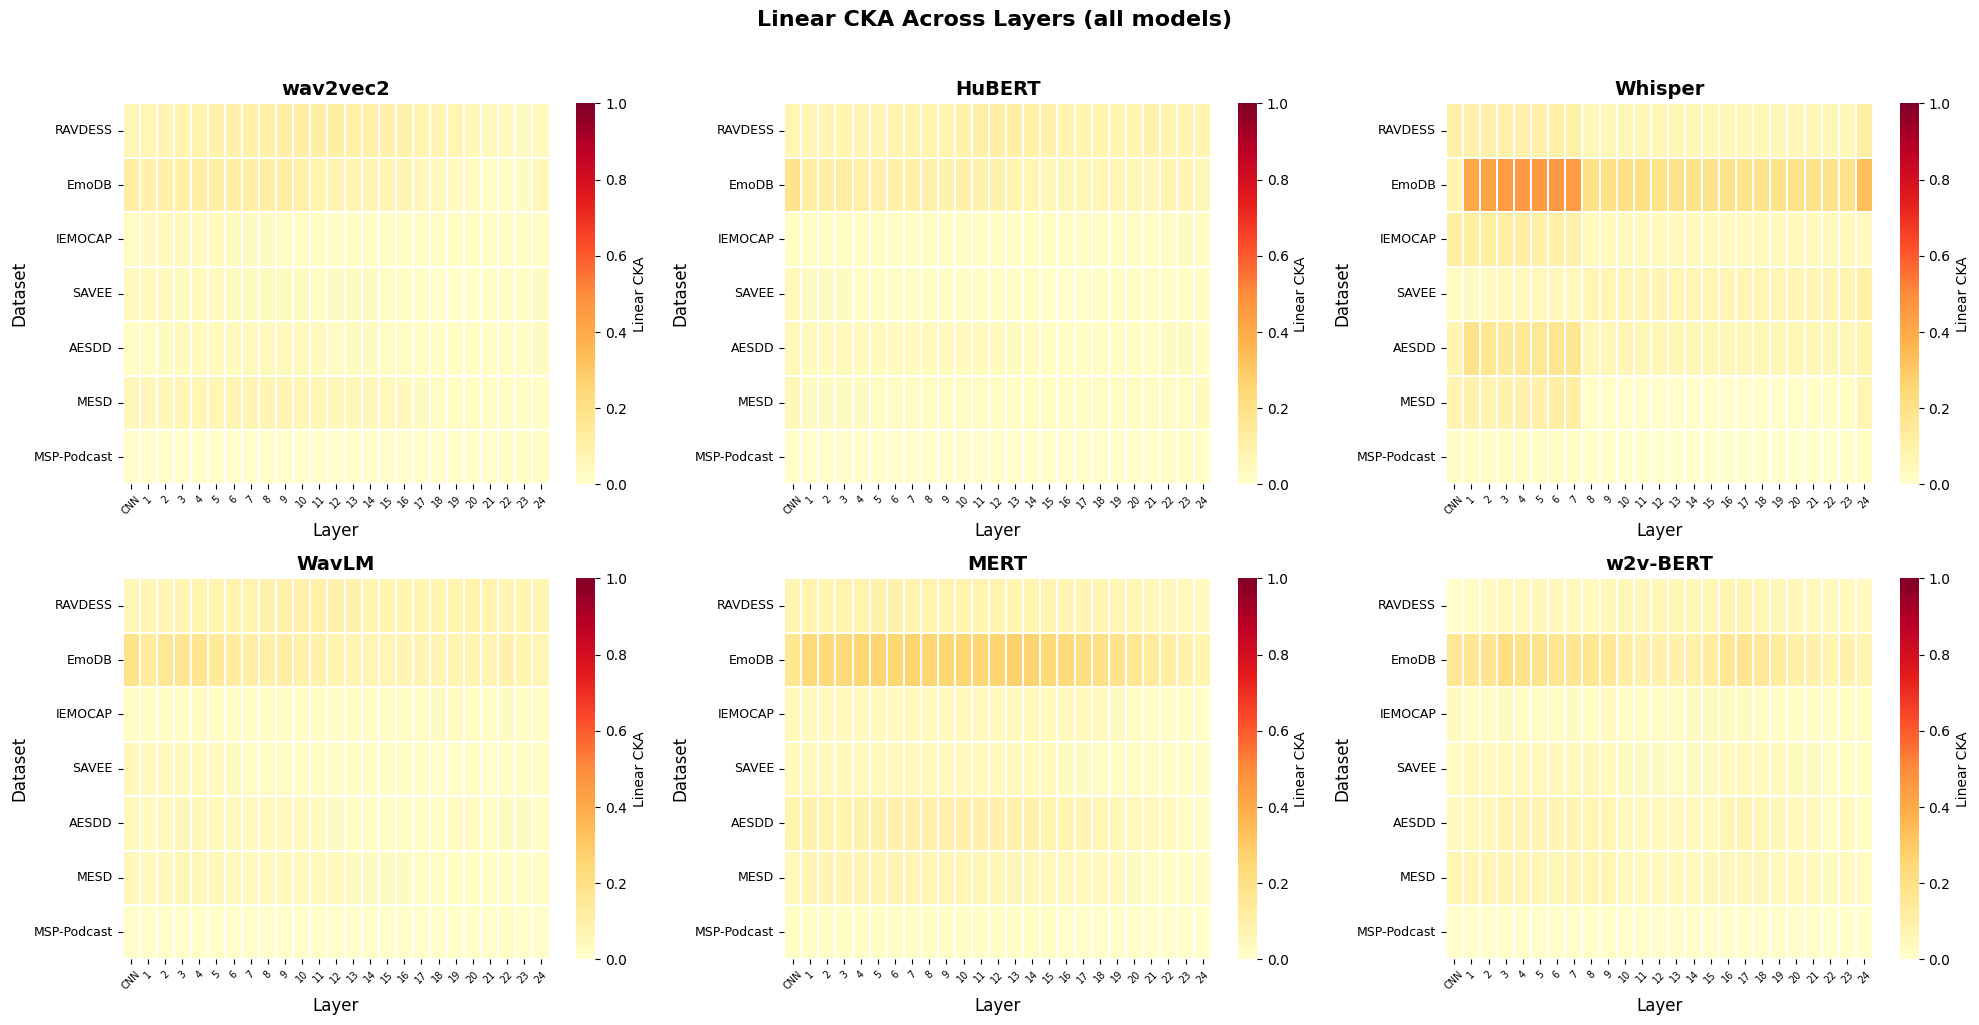

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/heatmap_cka.png


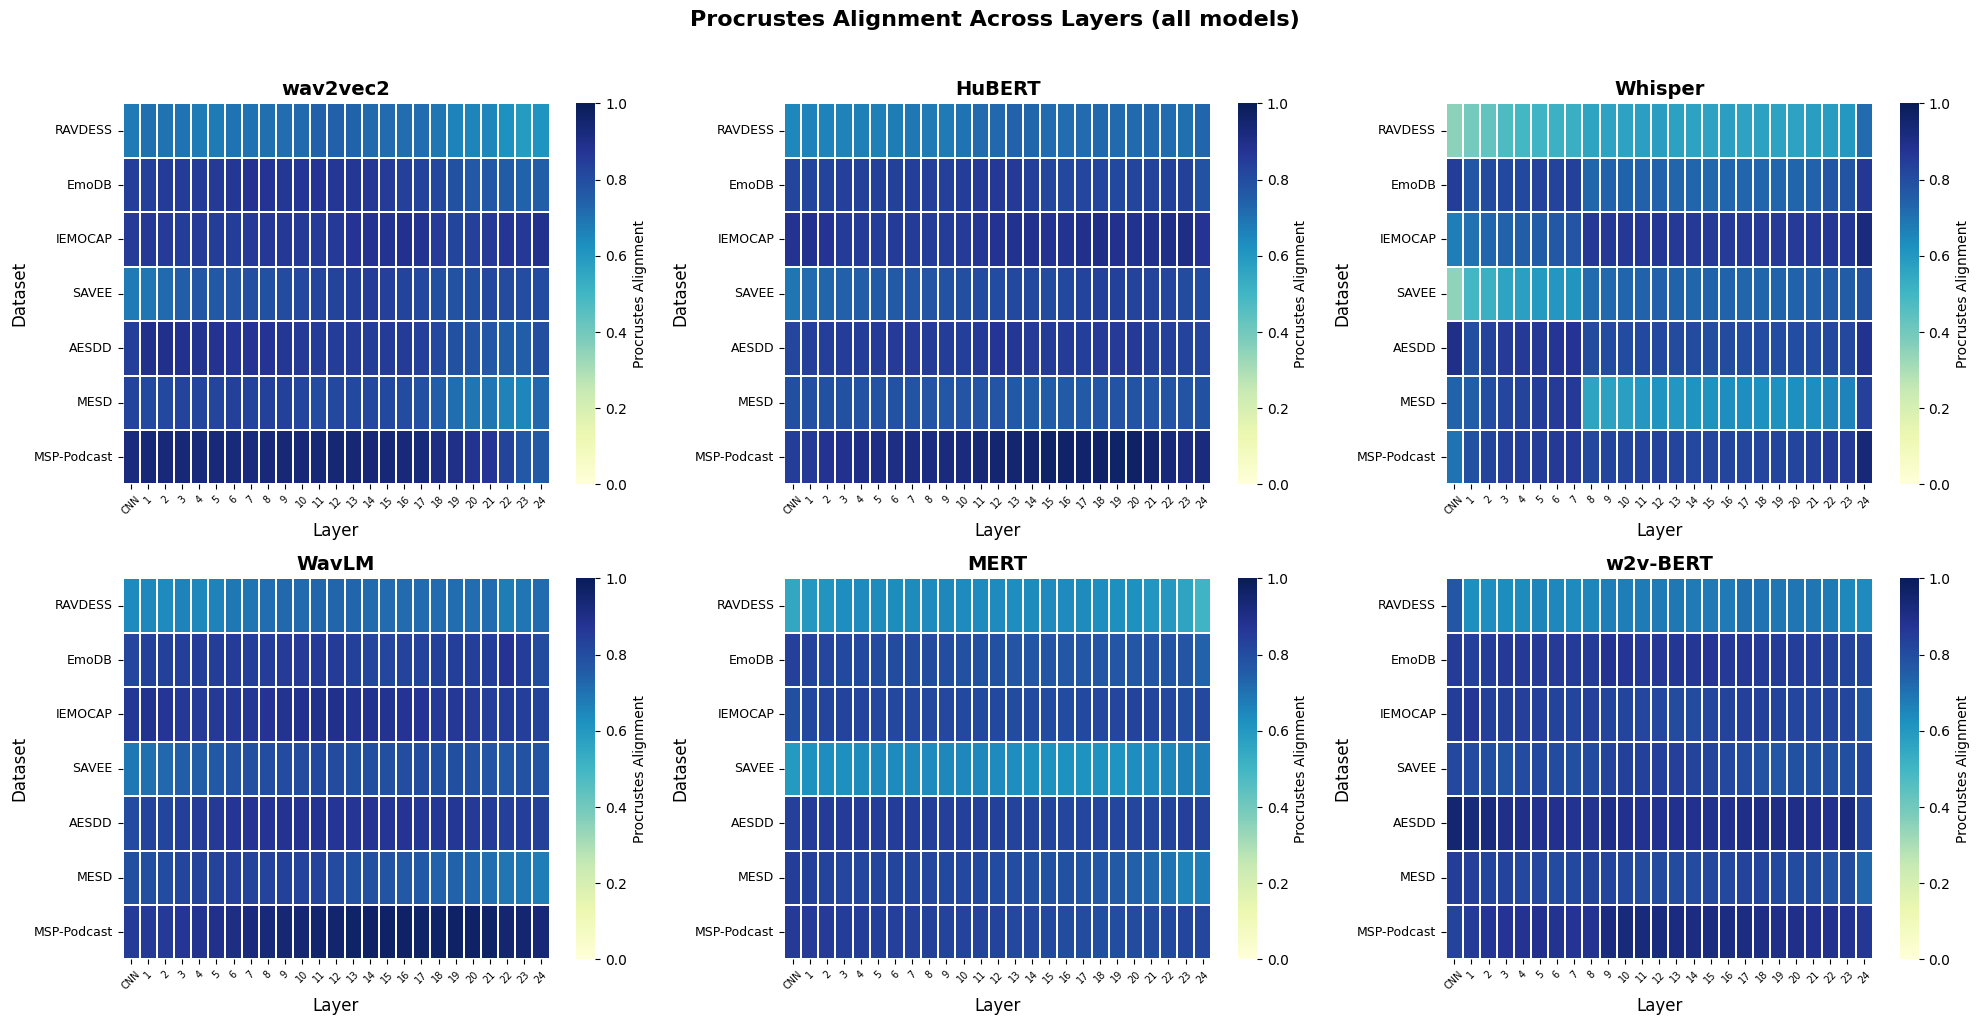

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/heatmap_procrustes.png


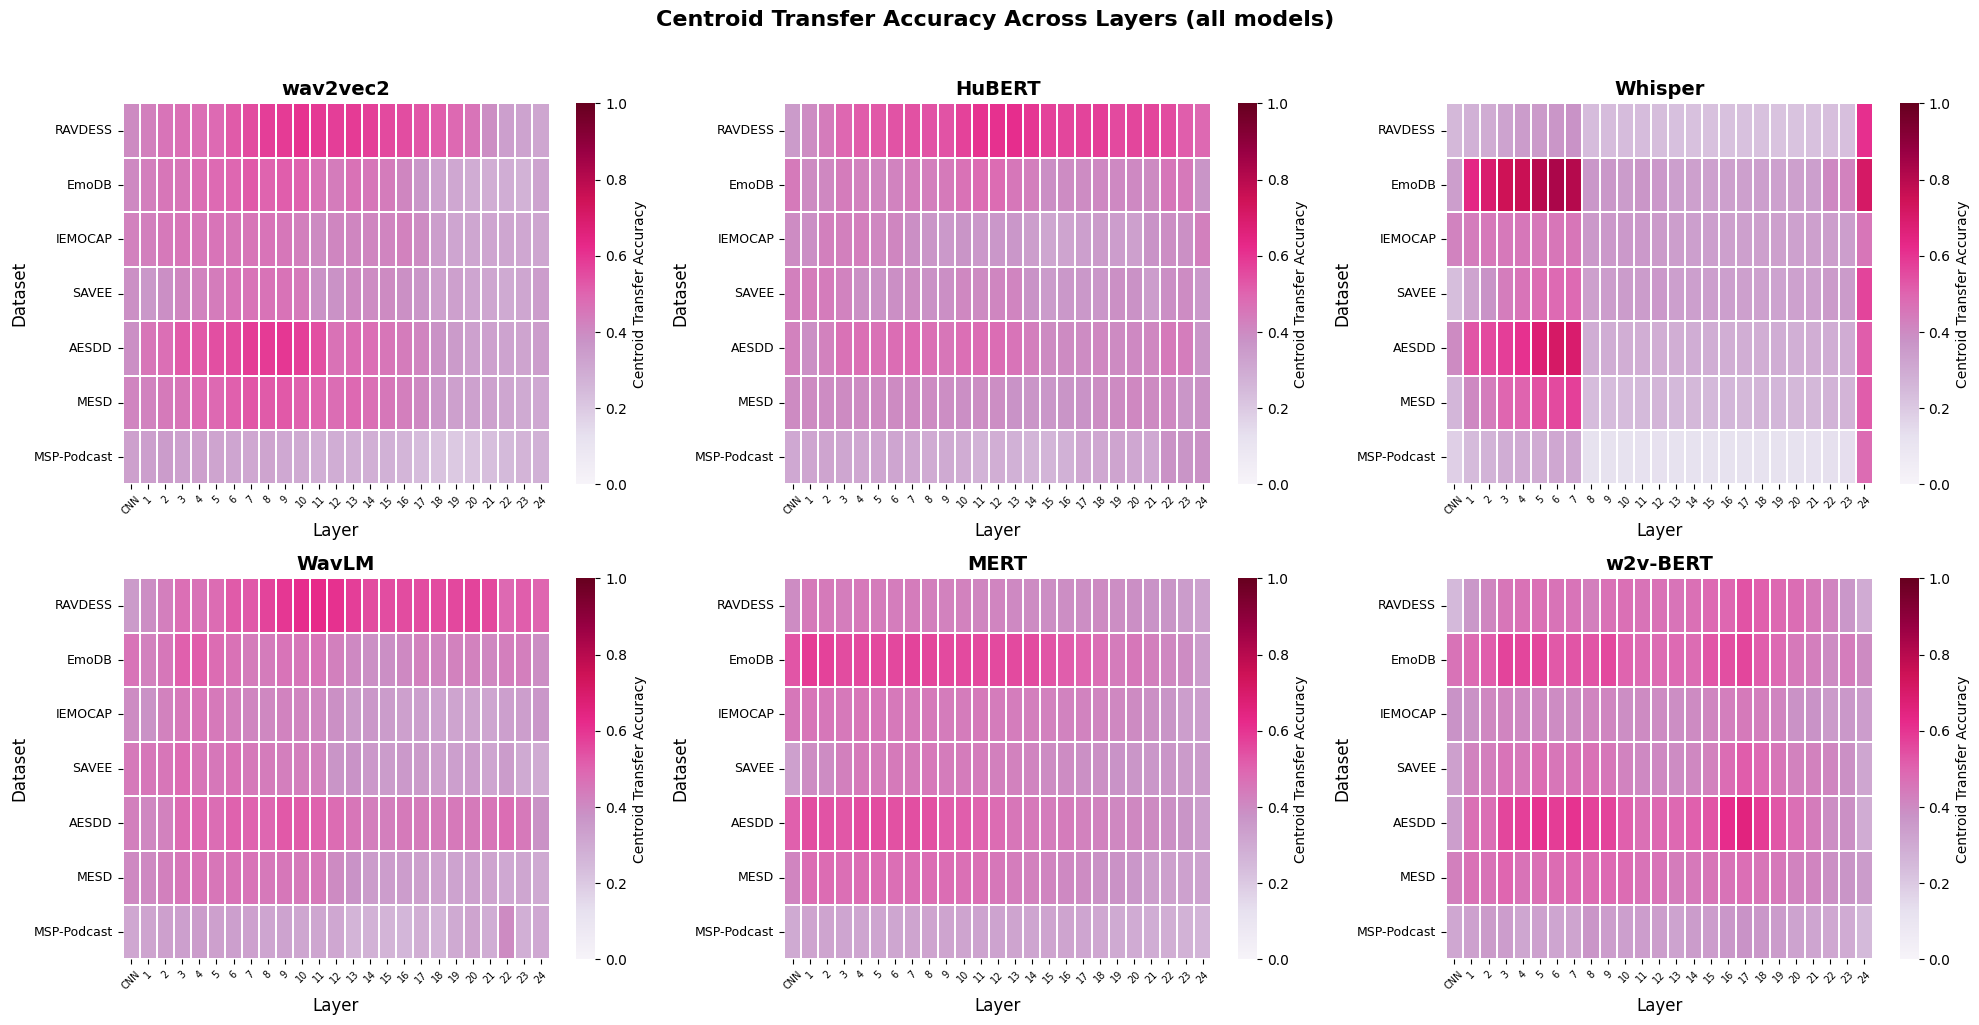

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/heatmap_centroid_transfer.png


In [9]:
def plot_metric_heatmap(metric_key, metric_label, cmap, out_name):
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()

    for idx, model in enumerate(MODELS):
        ax = axes[idx]
        matrix = []
        dataset_labels = []
        for dataset in DATASETS:
            key = (model, dataset)
            if key in alignment_results:
                matrix.append(alignment_results[key][metric_key])
                dataset_labels.append(dataset)
        if not matrix:
            ax.set_visible(False)
            continue
        matrix = np.array(matrix)

        sns.heatmap(
            matrix, ax=ax,
            xticklabels=LAYER_LABELS,
            yticklabels=dataset_labels,
            cmap=cmap, vmin=0, vmax=1,
            cbar_kws={'label': metric_label},
            linewidths=0.3,
        )
        ax.set_title(f'{model}', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
        ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
        ax.set_ylabel('Dataset', fontsize=PLOT_STYLE['label_fontsize'])
        ax.tick_params(axis='x', labelsize=7, rotation=45)
        ax.tick_params(axis='y', labelsize=9)

    plt.suptitle(f'{metric_label} Across Layers (all models)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, out_name)
    plt.savefig(out_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {out_path}")


plot_metric_heatmap('cka', 'Linear CKA', 'YlOrRd', 'heatmap_cka.png')
plot_metric_heatmap('procrustes', 'Procrustes Alignment', 'YlGnBu', 'heatmap_procrustes.png')
plot_metric_heatmap('centroid_transfer', 'Centroid Transfer Accuracy', 'PuRd', 'heatmap_centroid_transfer.png')


## 9. Acted vs Spontaneous: Does Text-Alignment Peak Earlier for Natural Speech?

Frozen probing showed IEMOCAP and MSP-Podcast peak at lower (acoustic) layers while
acted datasets peak at middle (semantic) layers. Does BERT alignment mirror that trend?
If yes, the speech model's text-like emotion structure lives in the *middle* layers --
which are exactly the ones the acted-speech probes highlighted.


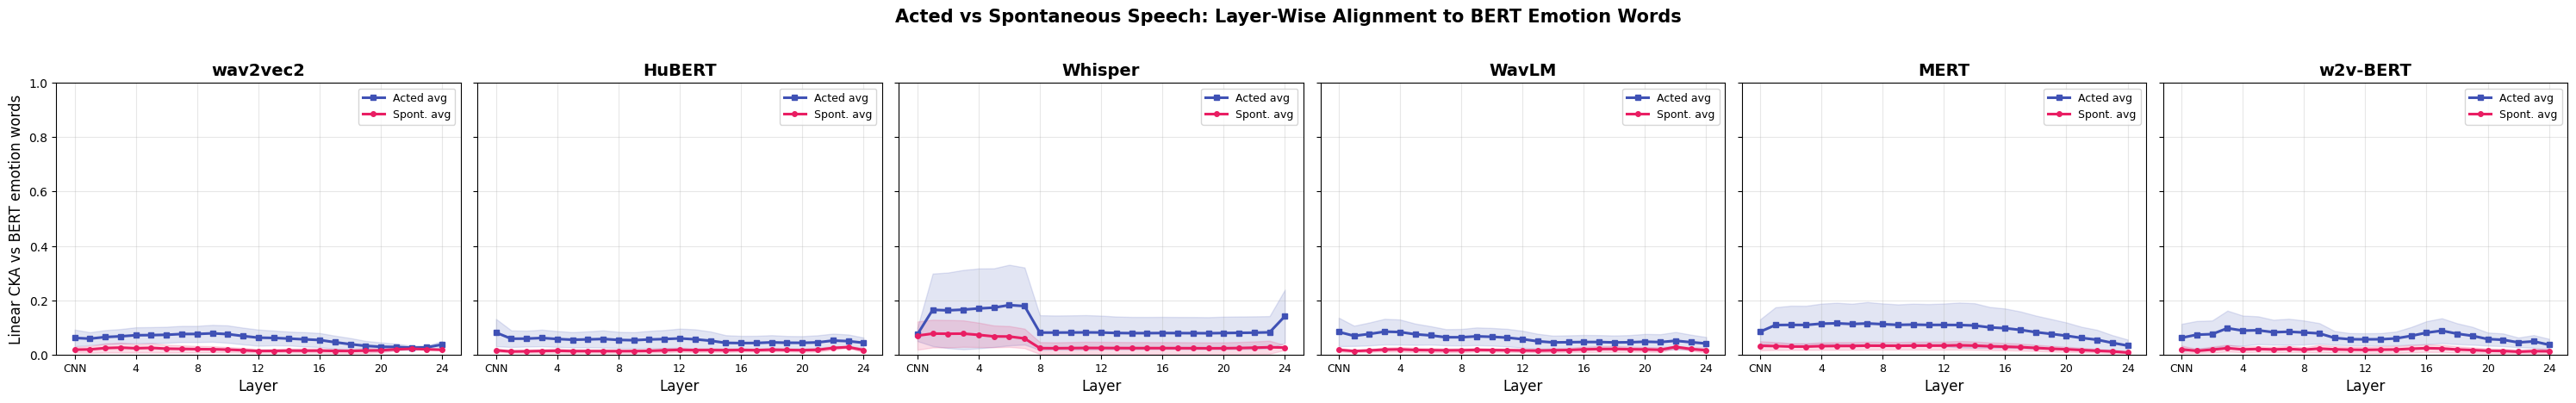

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/acted_vs_spontaneous_cka.png


In [10]:
ACTED = ['RAVDESS', 'EmoDB', 'SAVEE', 'AESDD', 'MESD']
SPONTANEOUS = ['IEMOCAP', 'MSP-Podcast']

fig, axes = plt.subplots(1, len(MODELS), figsize=(5.0 * len(MODELS), 4.5), sharey=True)
axes = np.array(axes).flatten()

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    layers = np.arange(NUM_LAYERS)

    acted_ckas = [alignment_results[(model, d)]['cka']
                  for d in ACTED if (model, d) in alignment_results]
    spont_ckas = [alignment_results[(model, d)]['cka']
                  for d in SPONTANEOUS if (model, d) in alignment_results]

    if acted_ckas:
        ac_mean = np.mean(acted_ckas, axis=0)
        ac_std  = np.std(acted_ckas, axis=0)
        ax.plot(layers, ac_mean, color='#3F51B5', marker='s', linewidth=2.2,
                label='Acted avg', markersize=4)
        ax.fill_between(layers, ac_mean - ac_std, ac_mean + ac_std,
                        color='#3F51B5', alpha=0.15)
    if spont_ckas:
        sp_mean = np.mean(spont_ckas, axis=0)
        sp_std  = np.std(spont_ckas, axis=0)
        ax.plot(layers, sp_mean, color='#E91E63', marker='o', linewidth=2.2,
                label='Spont. avg', markersize=4)
        ax.fill_between(layers, sp_mean - sp_std, sp_mean + sp_std,
                        color='#E91E63', alpha=0.15)

    ax.set_title(f'{model}', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
    if idx == 0:
        ax.set_ylabel('Linear CKA vs BERT emotion words',
                      fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_xticks(range(0, 25, 4))
    ax.set_xticklabels([LAYER_LABELS[i] for i in range(0, 25, 4)], fontsize=9)
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Acted vs Spontaneous Speech: Layer-Wise Alignment to BERT Emotion Words',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()

path = os.path.join(RESULTS_DIR, 'acted_vs_spontaneous_cka.png')
plt.savefig(path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {path}")


## 10. Save All Results

Dump per-experiment metric arrays to disk so downstream notebooks (and the final paper)
can read them back without re-running BERT.


In [11]:
# 1. Wide per-layer CSV -- one row per (model, dataset, metric), 25 layer columns
long_rows = []
for (model, dataset), res in alignment_results.items():
    for metric in ('cka', 'procrustes', 'centroid_transfer'):
        row = {'Model': model, 'Dataset': dataset, 'Metric': metric}
        for i, lbl in enumerate(LAYER_LABELS):
            row[f'Layer_{lbl}'] = float(res[metric][i])
        long_rows.append(row)

wide_df = pd.DataFrame(long_rows)
wide_path = os.path.join(RESULTS_DIR, 'alignment_per_layer_wide.csv')
wide_df.to_csv(wide_path, index=False)
print(f"Saved: {wide_path}")

# 2. Summary table -- best layer per metric per experiment
summary_rows = []
for (model, dataset), res in alignment_results.items():
    for metric in ('cka', 'procrustes', 'centroid_transfer'):
        vec = res[metric]
        best_idx = int(np.argmax(vec))
        summary_rows.append({
            'Model': model,
            'Dataset': dataset,
            'Metric': metric,
            'Best_Layer': LAYER_LABELS[best_idx],
            'Best_Layer_Num': best_idx,
            'Best_Value': float(vec[best_idx]),
            'Mean_Value': float(vec.mean()),
            'Max_Minus_Min': float(vec.max() - vec.min()),
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, 'alignment_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

# 3. NPZ archive for programmatic reuse
save_dict = {}
for (model, dataset), res in alignment_results.items():
    for metric in ('cka', 'procrustes', 'centroid_transfer'):
        save_dict[f'{model}__{dataset}__{metric}'] = res[metric]
np.savez(os.path.join(RESULTS_DIR, 'alignment_weights.npz'), **save_dict)
print(f"Saved: {os.path.join(RESULTS_DIR, 'alignment_weights.npz')}")

# 4. List outputs
print(f"\n{'='*60}")
print(f"All outputs in: {RESULTS_DIR}")
print(f"{'='*60}")
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, f)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  {f:<50} {size_mb:>8.2f} MB")


Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/alignment_per_layer_wide.csv
Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/alignment_summary.csv
Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment/alignment_weights.npz

All outputs in: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment
  acted_vs_spontaneous_cka.png                           0.37 MB
  alignment_curves_per_experiment.png                    1.66 MB
  alignment_per_layer_wide.csv                           0.06 MB
  alignment_summary.csv                                  0.01 MB
  alignment_weights.npz                                  0.06 MB
  heatmap_centroid_transfer.png                          0.32 MB
  heatmap_cka.png                                        0.29 MB
  heatmap_procrustes.png                                 0.31 MB
